## Bagging

Original data: [0 1 2 3 4 5 6 7 8 9]


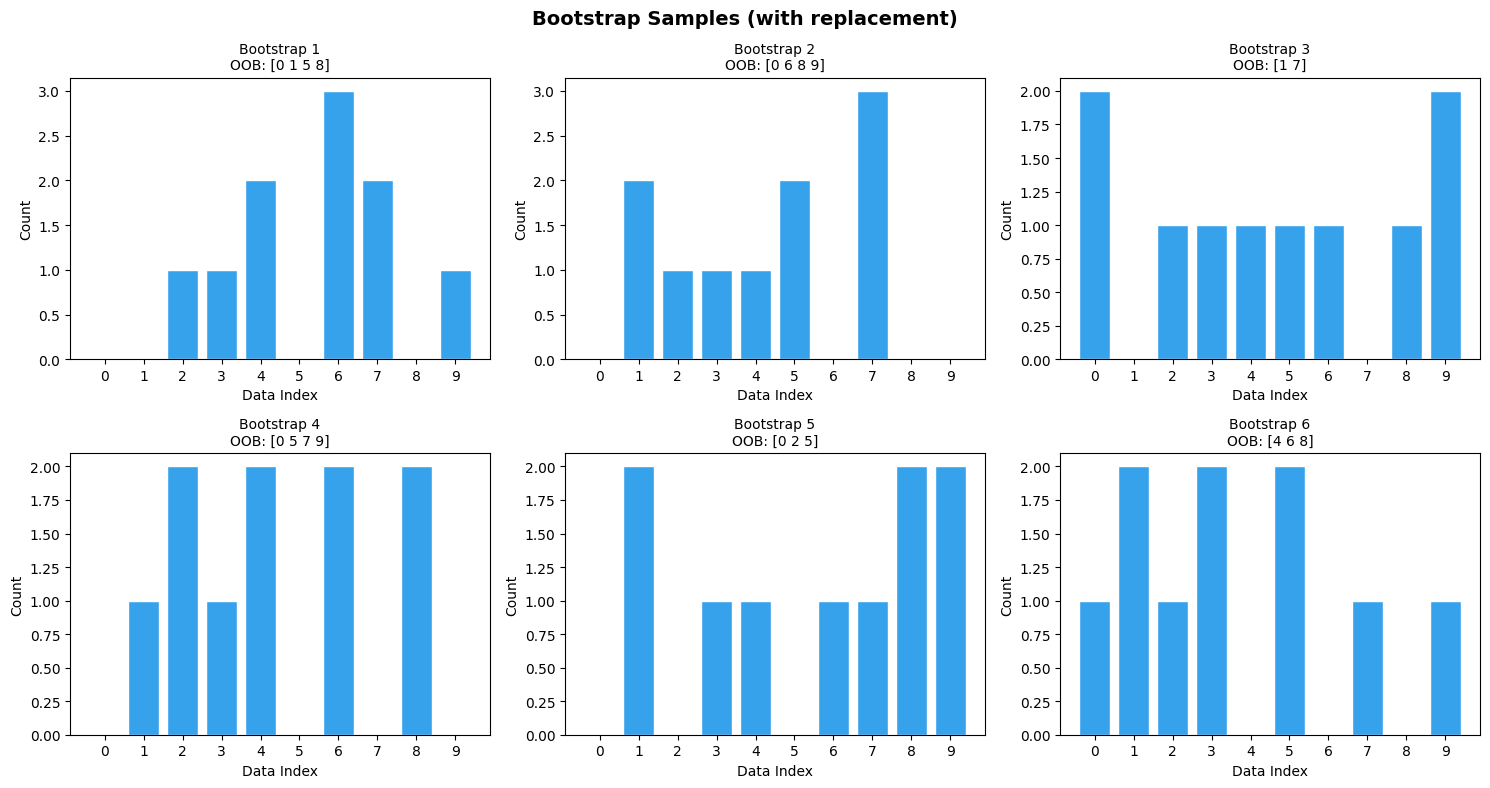


Average fraction of unique samples: 0.6333 (expected: 0.632)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate bootstrap sampling
np.random.seed(42)
original_data = np.arange(10)
print(f"Original data: {original_data}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    bootstrap = np.random.choice(original_data, size=len(original_data), replace=True)
    oob = np.setdiff1d(original_data, bootstrap)
    
    # Visualize
    ax.bar(range(10), np.bincount(bootstrap, minlength=10), color='#36A2EB', edgecolor='white')
    ax.set_title(f'Bootstrap {i+1}\nOOB: {oob}', fontsize=10)
    ax.set_xticks(range(10))
    ax.set_xlabel('Data Index')
    ax.set_ylabel('Count')

plt.suptitle('Bootstrap Samples (with replacement)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bootstrap_samples.png', dpi=150)
plt.show()

# Show that ~63.2% of data appears in each bootstrap
fractions = []
for _ in range(10000):
    sample = np.random.choice(100, size=100, replace=True)
    fractions.append(len(np.unique(sample)) / 100)
print(f"\nAverage fraction of unique samples: {np.mean(fractions):.4f} (expected: 0.632)")

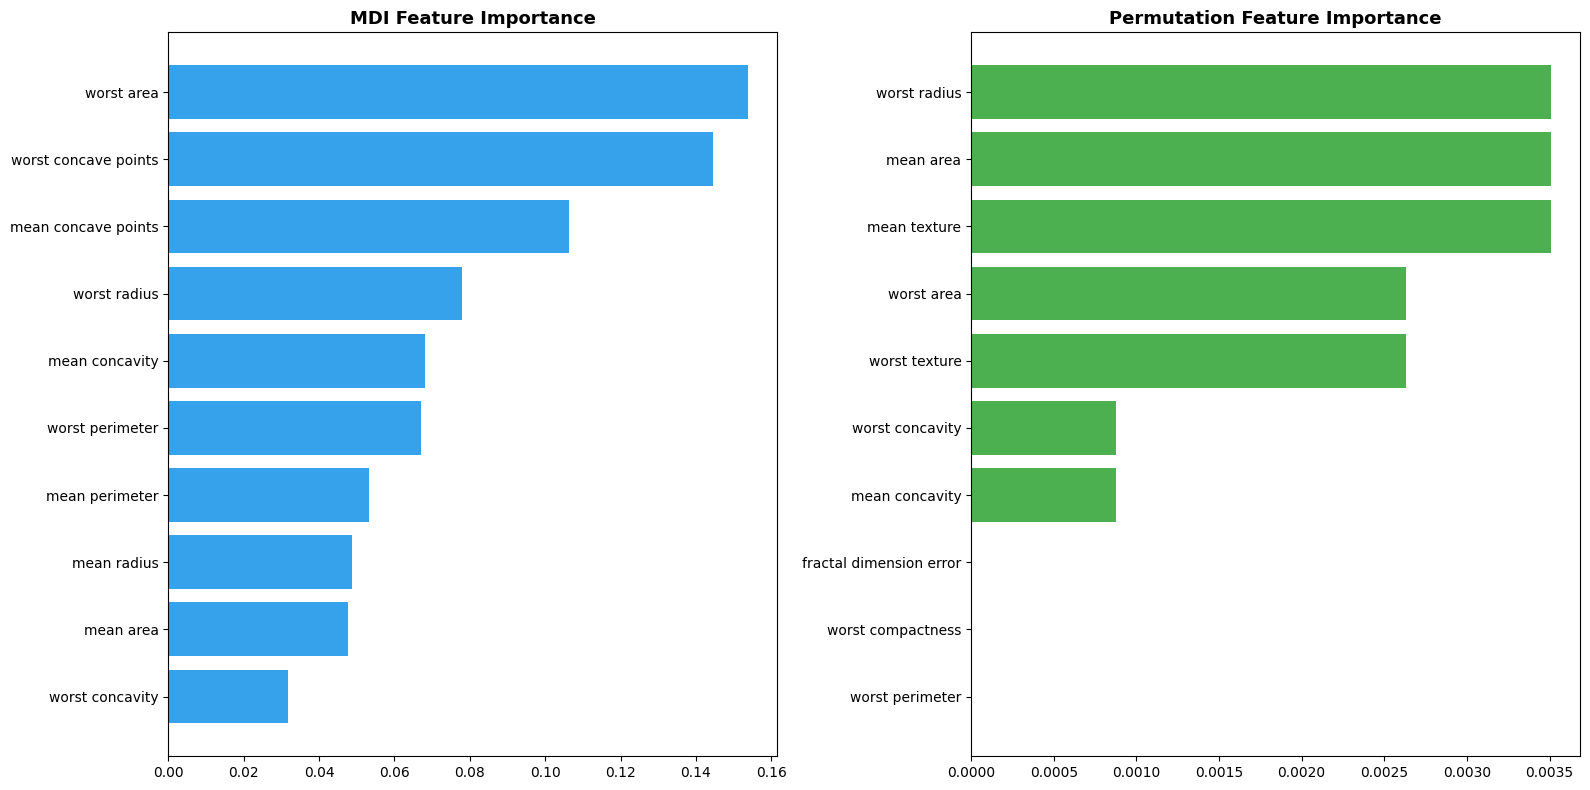

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# MDI importance
mdi_importance = rf.feature_importances_

# Permutation importance
perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# MDI
top_n = 10
idx = np.argsort(mdi_importance)[-top_n:]
axes[0].barh(range(top_n), mdi_importance[idx], color='#36A2EB')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([data.feature_names[i] for i in idx])
axes[0].set_title('MDI Feature Importance', fontsize=13, fontweight='bold')

# Permutation
idx = np.argsort(perm_importance.importances_mean)[-top_n:]
axes[1].barh(range(top_n), perm_importance.importances_mean[idx], color='#4CAF50')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([data.feature_names[i] for i in idx])
axes[1].set_title('Permutation Feature Importance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150)
plt.show()

In [4]:

import numpy as np
from collections import Counter

class SimpleDecisionTree:
    """Minimal decision tree for the Random Forest."""
    def __init__(self, max_depth=10, max_features=None):
        self.max_depth = max_depth
        self.max_features = max_features
        self.tree = None
    
    def _gini(self, y):
        counts = np.bincount(y)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)
    
    def _best_split(self, X, y):
        n_features = X.shape[1]
        # Random feature selection!
        if self.max_features:
            feature_indices = np.random.choice(n_features, self.max_features, replace=False)
        else:
            feature_indices = range(n_features)
        
        best_gain, best_feat, best_thresh = -1, None, None
        parent_gini = self._gini(y)
        
        for feat in feature_indices:
            thresholds = np.unique(X[:, feat])
            for thresh in thresholds:
                left = y[X[:, feat] <= thresh]
                right = y[X[:, feat] > thresh]
                if len(left) == 0 or len(right) == 0:
                    continue
                gain = parent_gini - (len(left)/len(y)*self._gini(left) + len(right)/len(y)*self._gini(right))
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, thresh
        
        return best_feat, best_thresh
    
    def _build(self, X, y, depth=0):
        if depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < 2:
            return Counter(y).most_common(1)[0][0]
        
        feat, thresh = self._best_split(X, y)
        if feat is None:
            return Counter(y).most_common(1)[0][0]
        
        left = X[:, feat] <= thresh
        return {
            'feature': feat, 'threshold': thresh,
            'left': self._build(X[left], y[left], depth+1),
            'right': self._build(X[~left], y[~left], depth+1)
        }
    
    def fit(self, X, y):
        self.tree = self._build(X, y)
        return self
    
    def _predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])
    
    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])


class RandomForestFromScratch:
    def __init__(self, n_estimators=10, max_depth=10, max_features='sqrt'):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        if self.max_features == 'sqrt':
            max_feat = int(np.sqrt(n_features))
        else:
            max_feat = n_features
        
        self.trees = []
        for _ in range(self.n_estimators):
            # Bootstrap sample
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot, y_boot = X[indices], y[indices]
            
            # Train tree with random feature selection
            tree = SimpleDecisionTree(max_depth=self.max_depth, max_features=max_feat)
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
        
        return self
    
    def predict(self, X):
        # Get predictions from all trees
        predictions = np.array([tree.predict(X) for tree in self.trees])
        # Majority vote
        return np.array([Counter(predictions[:, i]).most_common(1)[0][0] 
                         for i in range(X.shape[0])])
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# Test
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

rf = RandomForestFromScratch(n_estimators=50, max_depth=5)
rf.fit(X_train, y_train)
print(f"From-scratch RF accuracy: {rf.score(X_test, y_test):.2%}")

From-scratch RF accuracy: 100.00%


In [5]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

# Classification
rf = RandomForestClassifier(
    n_estimators=100,       # Number of trees
    max_depth=None,          # Grow full trees
    max_features='sqrt',     # √p features per split
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,          # Out-of-bag evaluation
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)
rf.fit(X_train, y_train)

print(f"Training accuracy: {rf.score(X_train, y_train):.4f}")
print(f"Test accuracy:     {rf.score(X_test, y_test):.4f}")
print(f"OOB score:         {rf.oob_score_:.4f}")

Training accuracy: 1.0000
Test accuracy:     0.9649
OOB score:         0.9560


In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    'n_estimators': randint(50, 500),
    'max_depth': [None, 5, 10, 20, 30],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions, n_iter=50, cv=5,
    scoring='accuracy', random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV score: {search.best_score_:.4f}")
print(f"Test score: {search.score(X_test, y_test):.4f}")

Best params: {'max_depth': 30, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 58}
Best CV score: 0.9670
Test score: 0.9561


## Boosting

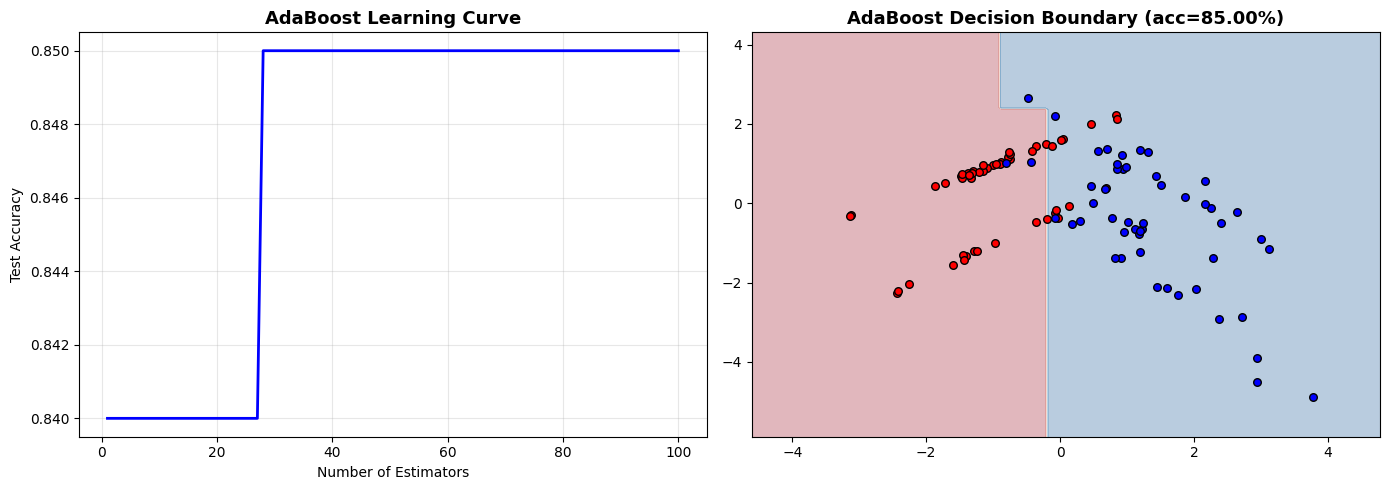

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_clusters_per_class=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# AdaBoost with decision stumps
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Weak learner: decision stump
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train, y_train)

# Show how accuracy improves with more estimators
staged_scores = list(ada.staged_score(X_test, y_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curve
axes[0].plot(range(1, len(staged_scores)+1), staged_scores, 'b-', linewidth=2)
axes[0].set_xlabel('Number of Estimators')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('AdaBoost Learning Curve', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Decision boundary
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200), np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 200))
Z = ada.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, cmap='RdBu', alpha=0.3)
axes[1].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='red', edgecolor='black', s=30)
axes[1].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='blue', edgecolor='black', s=30)
axes[1].set_title(f'AdaBoost Decision Boundary (acc={ada.score(X_test, y_test):.2%})', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('adaboost.png', dpi=150)
plt.show()

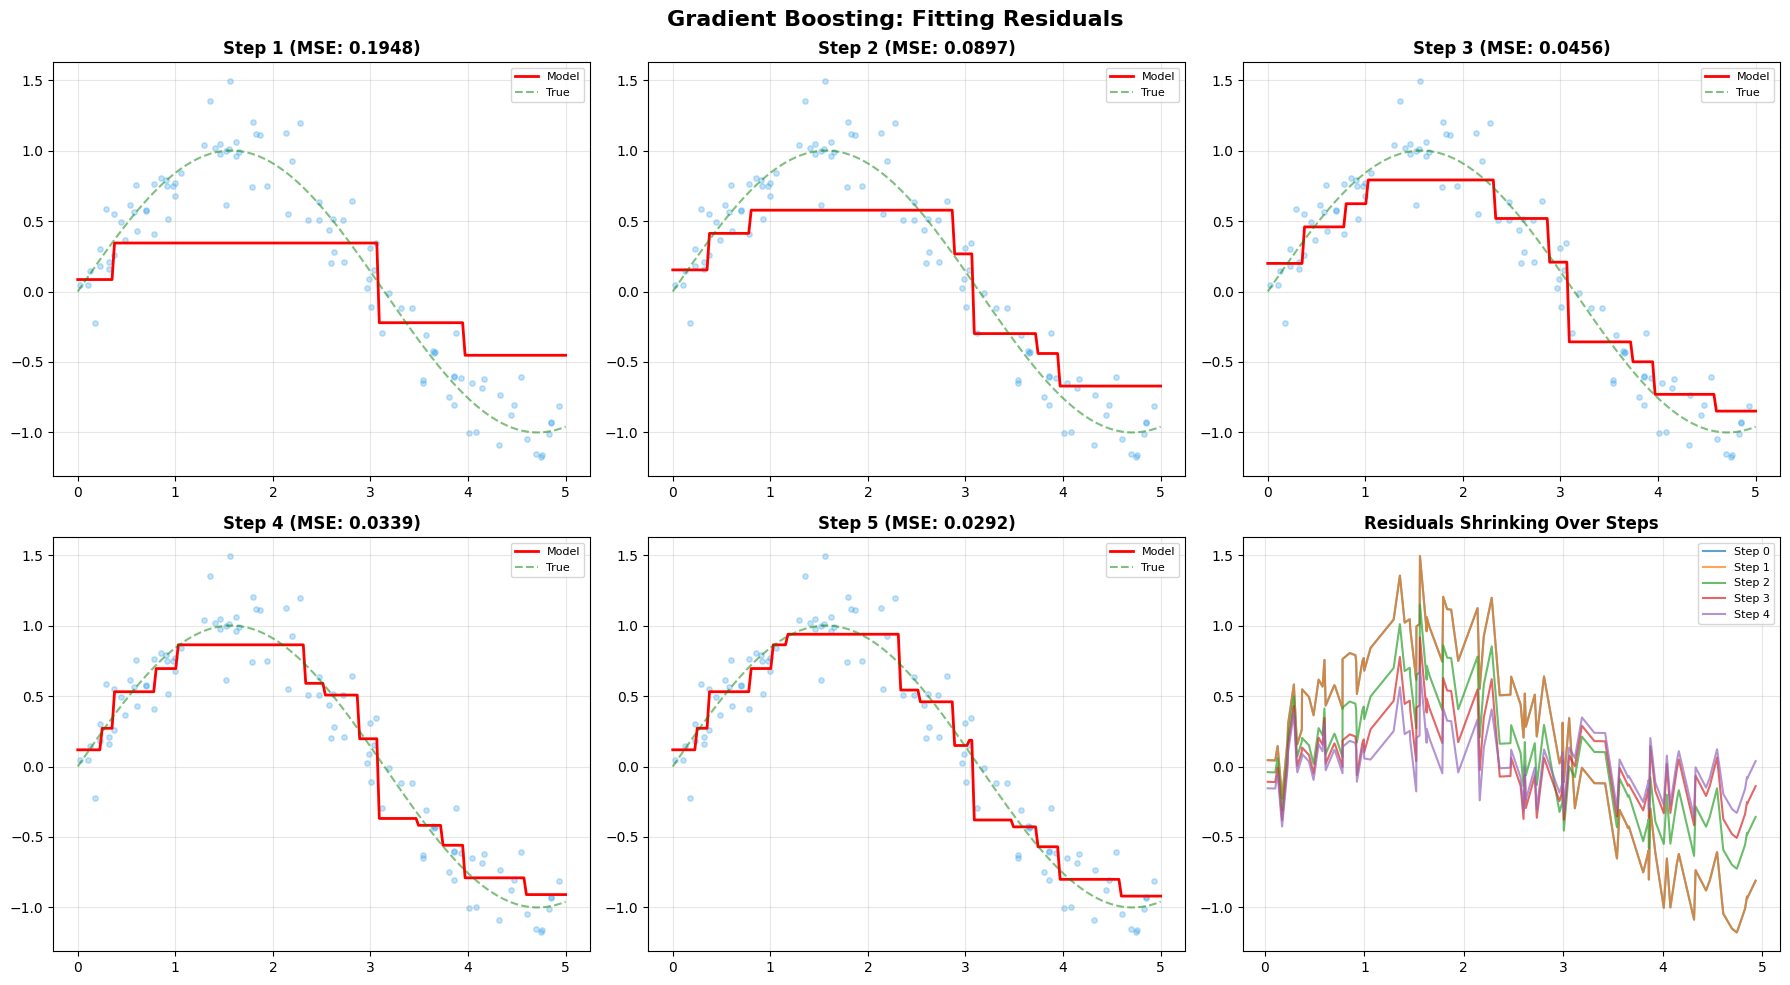

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gradient Boosting from scratch (for regression)
np.random.seed(42)
X = np.sort(np.random.uniform(0, 5, 100)).reshape(-1, 1)
y = np.sin(X.ravel()) + np.random.randn(100) * 0.2

from sklearn.tree import DecisionTreeRegressor

n_estimators = 5
learning_rate = 0.5
trees = []
predictions = np.zeros(len(y))
residuals_history = [y.copy()]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
X_plot = np.linspace(0, 5, 200).reshape(-1, 1)

for i in range(n_estimators):
    # Compute residuals
    residuals = y - predictions
    residuals_history.append(residuals.copy())
    
    # Fit tree to residuals
    tree = DecisionTreeRegressor(max_depth=2)
    tree.fit(X, residuals)
    trees.append(tree)
    
    # Update predictions
    predictions += learning_rate * tree.predict(X)
    
    # Plot
    ax = axes.flat[i]
    ax.scatter(X, y, alpha=0.3, s=15, color='#36A2EB')
    ax.plot(X_plot, sum(learning_rate * t.predict(X_plot) for t in trees), 'r-', linewidth=2, label='Model')
    ax.plot(X_plot, np.sin(X_plot.ravel()), 'g--', alpha=0.5, label='True')
    mse = np.mean((y - predictions)**2)
    ax.set_title(f'Step {i+1} (MSE: {mse:.4f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Show residuals in last panel
ax = axes.flat[5]
for i, res in enumerate(residuals_history[:5]):
    ax.plot(np.sort(X.ravel()), res[np.argsort(X.ravel())], alpha=0.7, label=f'Step {i}')
ax.set_title('Residuals Shrinking Over Steps', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Gradient Boosting: Fitting Residuals', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('gradient_boosting.png', dpi=150)
plt.show()

In [10]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,      # Stochastic GB: use 80% of samples
    random_state=42
)
gb.fit(X_train, y_train)
print(f"Test accuracy: {gb.score(X_test, y_test):.4f}")

Test accuracy: 0.9561


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [19:24:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost accuracy: 0.9649


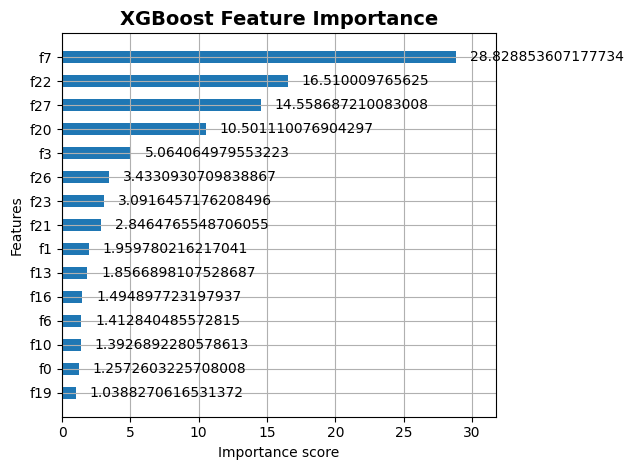

In [12]:
# pip install xgboost
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,          # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print(f"XGBoost accuracy: {model.score(X_test, y_test):.4f}")

# Feature importance
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=15, importance_type='gain', height=0.5)
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('xgboost_importance.png', dpi=150)
plt.show()

In [13]:
# pip install lightgbm
import lightgbm as lgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=-1,          # No limit (leaf-wise growth controls this)
    num_leaves=31,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)
print(f"LightGBM accuracy: {model.score(X_test, y_test):.4f}")

LightGBM accuracy: 0.9737


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
# pip install catboost
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    l2_leaf_reg=3,
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)
print(f"CatBoost accuracy: {model.score(X_test, y_test):.4f}")

CatBoost accuracy: 0.9649


In [16]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_breast_cancer
import numpy as np

data = load_breast_cancer()
X, y = data.data, data.target

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Try to import optional libraries
try:
    import xgboost as xgb
    models['XGBoost'] = xgb.XGBClassifier(n_estimators=100, eval_metric='logloss', use_label_encoder=False, random_state=42, verbosity=0)
except ImportError:
    pass

try:
    import lightgbm as lgb
    models['LightGBM'] = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
except ImportError:
    pass

print(f"{'Model':<25} {'Mean CV Score':>15} {'Std':>10}")
print("-" * 55)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():>15.4f} {scores.std():>10.4f}")

Model                       Mean CV Score        Std
-------------------------------------------------------
Random Forest                      0.9561     0.0228
Gradient Boosting                  0.9631     0.0210
XGBoost                            0.9736     0.0147


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM                           0.9701     0.0172


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Stacking and Voting

In [17]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

# Define base models
estimators = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
]

# Hard voting
hard_voting = VotingClassifier(estimators=estimators, voting='hard')
# Soft voting
soft_voting = VotingClassifier(estimators=estimators, voting='soft')

# Compare
print(f"{'Model':<30} {'CV Score':>10}")
print("-" * 42)
for name, model in estimators + [('Hard Voting', hard_voting), ('Soft Voting', soft_voting)]:
    scores = cross_val_score(model, data.data, data.target, cv=5, scoring='accuracy')
    print(f"{name:<30} {scores.mean():>10.4f} ± {scores.std():.4f}")

Model                            CV Score
------------------------------------------


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

lr                                 0.9526 ± 0.0142
rf                                 0.9561 ± 0.0228
gb                                 0.9631 ± 0.0210
svm                                0.9122 ± 0.0354


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

Hard Voting                        0.9667 ± 0.0238


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

Soft Voting                        0.9719 ± 0.0187


In [18]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

# Base models
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(probability=True, random_state=42))
]

# Stacking with Logistic Regression as meta-learner
stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,                    # 5-fold CV for base predictions
    stack_method='predict_proba',  # Use probabilities, not hard predictions
    n_jobs=-1
)

stacking.fit(X_train, y_train)
print(f"Stacking test accuracy: {stacking.score(X_test, y_test):.4f}")

# Compare with individual models
print(f"\nIndividual model scores:")
for name, model in base_estimators:
    model.fit(X_train, y_train)
    print(f"  {name}: {model.score(X_test, y_test):.4f}")

Stacking test accuracy: 0.9737

Individual model scores:
  rf: 0.9649
  gb: 0.9561
  knn: 0.9561
  svm: 0.9474


In [19]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X_train_full, X_test, y_train_full, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

# Split training into train and blend sets
X_train, X_blend, y_train, y_blend = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=42)

# Train base models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# Create blend features (predictions on blend set)
blend_features = np.column_stack([
    rf.predict_proba(X_blend)[:, 1],
    gb.predict_proba(X_blend)[:, 1]
])

# Train meta-learner on blend features
meta = LogisticRegression()
meta.fit(blend_features, y_blend)

# Predict on test set
test_features = np.column_stack([
    rf.predict_proba(X_test)[:, 1],
    gb.predict_proba(X_test)[:, 1]
])
print(f"Blending accuracy: {meta.score(test_features, y_test):.4f}")

Blending accuracy: 0.9649
